Libraries loaded successfully!
Please upload an image file (jpg, jpeg, png)...


Saving Gemini_Generated_Image_vx73o8vx73o8vx73.png to Gemini_Generated_Image_vx73o8vx73o8vx73.png
   Image 'Gemini_Generated_Image_vx73o8vx73o8vx73.png' loaded successfully!
   Resolution : 2394 x 1792 px
   Channels   : 3

🎯 Detection complete!
   Raw detections (before NMS) : 4
   After NMS filtering         : 4
   Face 1: Position=(394,423)  Size=461x461px
   Face 2: Position=(1223,542)  Size=449x449px
   Face 3: Position=(1646,528)  Size=448x448px
   Face 4: Position=(822,498)  Size=443x443px
✅ Haar Feature Response Map generated!


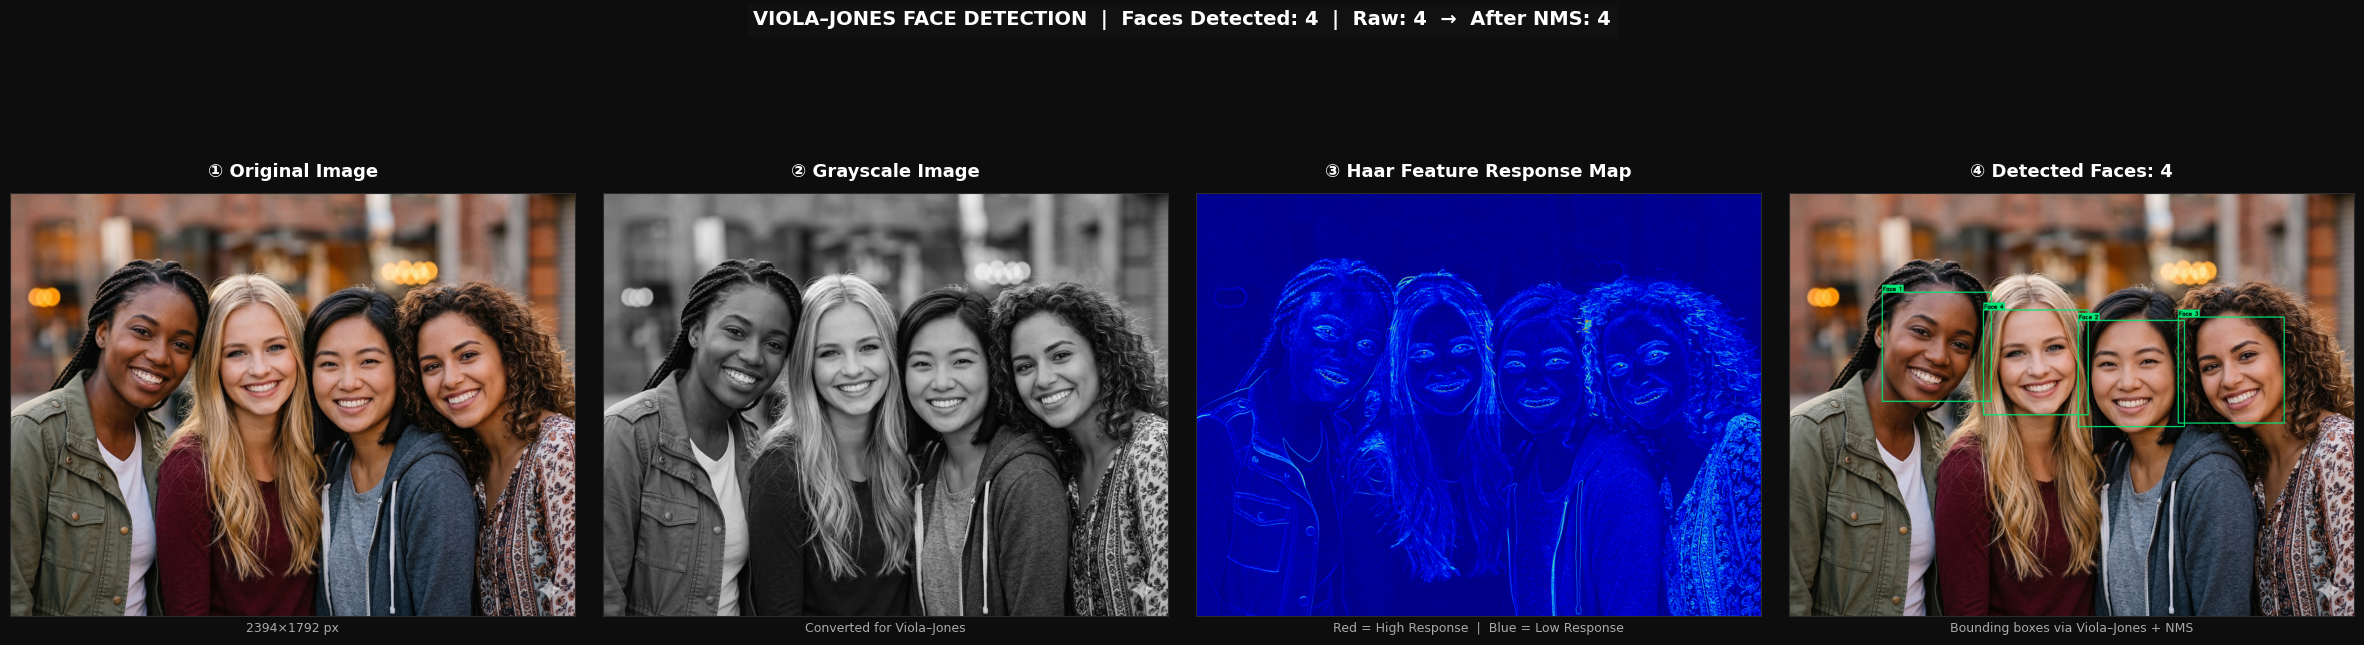


══════════════════════════════════════════════════
  VIOLA–JONES FACE DETECTION — SUMMARY
──────────────────────────────────────────────────
  Algorithm     : Viola–Jones (Haar Cascade)
  Classifier    : haarcascade_frontalface_default
  Scale Factor  : 1.2
  Min Neighbors : 8
  Min Face Size : 80 × 80 px
  NMS Threshold : 0.3 IoU
──────────────────────────────────────────────────
  Raw Detections: 4
  After NMS     : 4
  ✅ Output saved → face_detection_output.png
══════════════════════════════════════════════════


In [7]:

import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from google.colab import files
from IPython.display import display
from PIL import Image
import io

print("Libraries loaded successfully!")
print("Please upload an image file (jpg, jpeg, png)...")
uploaded = files.upload()

filename     = list(uploaded.keys())[0]
image_data   = uploaded[filename]
image_array  = np.frombuffer(image_data, dtype=np.uint8)
original_img = cv2.imdecode(image_array, cv2.IMREAD_COLOR)
original_rgb = cv2.cvtColor(original_img, cv2.COLOR_BGR2RGB)

print(f"   Image '{filename}' loaded successfully!")
print(f"   Resolution : {original_img.shape[1]} x {original_img.shape[0]} px")
print(f"   Channels   : {original_img.shape[2]}")

face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')
gray_img = cv2.cvtColor(original_img, cv2.COLOR_BGR2GRAY)
gray_eq = cv2.equalizeHist(gray_img)
faces_raw = face_cascade.detectMultiScale(
    gray_eq,
    scaleFactor  = 1.2,
    minNeighbors = 8,
    minSize      = (80, 80),
    flags        = cv2.CASCADE_SCALE_IMAGE
)

def apply_nms(boxes, overlap_threshold=0.3):
    """Merges overlapping bounding boxes that represent the same face."""
    if len(boxes) == 0:
        return []

    boxes_xyxy = [[x, y, x + w, y + h] for (x, y, w, h) in boxes]
    boxes_np   = np.array(boxes_xyxy, dtype=np.float32)

    x1, y1 = boxes_np[:, 0], boxes_np[:, 1]
    x2, y2 = boxes_np[:, 2], boxes_np[:, 3]
    areas  = (x2 - x1) * (y2 - y1)
    order  = areas.argsort()[::-1]
    keep   = []

    while len(order) > 0:
        i = order[0]
        keep.append(i)
        if len(order) == 1:
            break
        rest = order[1:]
        ix1  = np.maximum(x1[i], x1[rest])
        iy1  = np.maximum(y1[i], y1[rest])
        ix2  = np.minimum(x2[i], x2[rest])
        iy2  = np.minimum(y2[i], y2[rest])
        inter = np.maximum(0, ix2 - ix1) * np.maximum(0, iy2 - iy1)
        iou   = inter / (areas[i] + areas[rest] - inter)
        order = rest[iou <= overlap_threshold]

    return [(int(boxes_np[i, 0]), int(boxes_np[i, 1]),
             int(boxes_np[i, 2] - boxes_np[i, 0]),
             int(boxes_np[i, 3] - boxes_np[i, 1])) for i in keep]


faces_nms = apply_nms(faces_raw, overlap_threshold=0.3) if len(faces_raw) > 0 else []
faces     = np.array(faces_nms) if len(faces_nms) > 0 else np.array([])

total_faces = len(faces)

print(f"\n🎯 Detection complete!")
print(f"   Raw detections (before NMS) : {len(faces_raw) if len(faces_raw) > 0 else 0}")
print(f"   After NMS filtering         : {total_faces}")
if total_faces > 0:
    for i, (x, y, w, h) in enumerate(faces):
        print(f"   Face {i+1}: Position=({x},{y})  Size={w}x{h}px")

def generate_haar_response_map(gray_image, detected_faces):
    """
    Simulates a Haar-like feature response map:
    1. Applies horizontal edge, vertical edge, and line Haar filters
    2. Combines responses as a heatmap
    3. Boosts face regions for visual clarity
    """
    img_float = gray_image.astype(np.float32) / 255.0

    kernel_h = np.array([[-1, -1, -1],
                          [ 1,  1,  1],
                          [ 0,  0,  0]], dtype=np.float32)

    kernel_v = np.array([[-1,  1,  0],
                          [-1,  1,  0],
                          [-1,  1,  0]], dtype=np.float32)

    kernel_l = np.array([[-1, -1, -1],
                          [ 2,  2,  2],
                          [-1, -1, -1]], dtype=np.float32)

    resp_h   = cv2.filter2D(img_float, -1, kernel_h)
    resp_v   = cv2.filter2D(img_float, -1, kernel_v)
    resp_l   = cv2.filter2D(img_float, -1, kernel_l)

    combined = (np.abs(resp_h) + np.abs(resp_v) + np.abs(resp_l)) / 3.0

    boosted = combined.copy()
    if len(detected_faces) > 0:
        for (x, y, w, h) in detected_faces:
            boosted[y:y+h, x:x+w] = np.clip(boosted[y:y+h, x:x+w] * 1.8, 0, 1)

    response_map  = cv2.normalize(boosted, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
    heatmap       = cv2.applyColorMap(response_map, cv2.COLORMAP_JET)
    heatmap_rgb   = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)

    return heatmap_rgb, response_map


haar_heatmap, haar_gray_map = generate_haar_response_map(gray_img, faces)
print("✅ Haar Feature Response Map generated!")

annotated_img = original_rgb.copy()

if total_faces > 0:
    for i, (x, y, w, h) in enumerate(faces):
        cv2.rectangle(annotated_img, (x, y), (x + w, y + h), (0, 230, 118), 3)

        label      = f"Face {i+1}"
        (tw, th), _ = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, 0.75, 2)
        cv2.rectangle(annotated_img, (x, y - th - 14), (x + tw + 6, y), (0, 230, 118), -1)
        cv2.putText(annotated_img, label, (x + 3, y - 6),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.75, (0, 0, 0), 2, cv2.LINE_AA)
else:

    cv2.putText(annotated_img, "No faces detected", (20, 50),
                cv2.FONT_HERSHEY_SIMPLEX, 1.0, (255, 80, 80), 2, cv2.LINE_AA)


fig, axes = plt.subplots(1, 4, figsize=(24, 7))
fig.patch.set_facecolor('#0d0d0d')

panel_configs = [
    {
        "img"      : original_rgb,
        "title"    : "① Original Image",
        "cmap"     : None,
        "subtitle" : f"{original_img.shape[1]}×{original_img.shape[0]} px"
    },
    {
        "img"      : gray_img,
        "title"    : "② Grayscale Image",
        "cmap"     : "gray",
        "subtitle" : "Converted for Viola–Jones"
    },
    {
        "img"      : haar_heatmap,
        "title"    : "③ Haar Feature Response Map",
        "cmap"     : None,
        "subtitle" : "Red = High Response  |  Blue = Low Response"
    },
    {
        "img"      : annotated_img,
        "title"    : f"④ Detected Faces: {total_faces}",
        "cmap"     : None,
        "subtitle" : "Bounding boxes via Viola–Jones + NMS"
    },
]

for ax, cfg in zip(axes, panel_configs):
    ax.set_facecolor('#1a1a1a')
    ax.imshow(cfg["img"], cmap=cfg["cmap"])
    ax.set_title(cfg["title"], color='white', fontsize=13,
                 fontweight='bold', pad=12)
    ax.set_xlabel(cfg["subtitle"], color='#aaaaaa', fontsize=9)
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_edgecolor('#2a2a2a')

plt.suptitle(
    f"VIOLA–JONES FACE DETECTION  |  Faces Detected: {total_faces}  "
    f"|  Raw: {len(faces_raw) if len(faces_raw) > 0 else 0}  →  After NMS: {total_faces}",
    color='white', fontsize=14, fontweight='bold',
    y=1.03, backgroundcolor='#111111'
)

plt.tight_layout(pad=2.0)
plt.savefig("face_detection_output.png", dpi=150,
            bbox_inches='tight', facecolor='#0d0d0d')
plt.show()

print(f"\n{'═'*50}")
print(f"  VIOLA–JONES FACE DETECTION — SUMMARY")
print(f"{'─'*50}")
print(f"  Algorithm     : Viola–Jones (Haar Cascade)")
print(f"  Classifier    : haarcascade_frontalface_default")
print(f"  Scale Factor  : 1.2")
print(f"  Min Neighbors : 8")
print(f"  Min Face Size : 80 × 80 px")
print(f"  NMS Threshold : 0.3 IoU")
print(f"{'─'*50}")
print(f"  Raw Detections: {len(faces_raw) if len(faces_raw) > 0 else 0}")
print(f"  After NMS     : {total_faces}")
print(f"  ✅ Output saved → face_detection_output.png")
print(f"{'═'*50}")
